<a href="https://colab.research.google.com/github/alexandrumoldovan1/housing-prices-ml/blob/main/notebooks/05_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Install ML libraries (needed to load saved models)
!pip install shap xgboost lightgbm catboost -q

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# ML libraries (needed for loading models)
import xgboost
import lightgbm
import catboost
import shap

# Sklearn imports
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay

# Visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.0 MB/s eta 0:00:00
Libraries imported successfully!


In [7]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths
DRIVE_PATH = '/content/drive/MyDrive/ColabProjects/housing-prices-ml'
PROCESSED_DATA_PATH = f'{DRIVE_PATH}/processed_data'
MODELS_PATH = f'{DRIVE_PATH}/models'
OUTPUTS_PATH = f'{DRIVE_PATH}/outputs'

# Load processed data
X_train = pd.read_parquet(f'{PROCESSED_DATA_PATH}/X_train.parquet')
X_test = pd.read_parquet(f'{PROCESSED_DATA_PATH}/X_test.parquet')
X_train_scaled = pd.read_parquet(f'{PROCESSED_DATA_PATH}/X_train_scaled.parquet')
X_test_scaled = pd.read_parquet(f'{PROCESSED_DATA_PATH}/X_test_scaled.parquet')
y_train = pd.read_parquet(f'{PROCESSED_DATA_PATH}/y_train.parquet').squeeze()
y_test = pd.read_parquet(f'{PROCESSED_DATA_PATH}/y_test.parquet').squeeze()

# Load all trained models (names must match results_df)
models = {
    'Linear Regression': joblib.load(f'{MODELS_PATH}/linear_regression.pkl'),
    'Ridge Regression': joblib.load(f'{MODELS_PATH}/ridge.pkl'),
    'Lasso Regression': joblib.load(f'{MODELS_PATH}/lasso.pkl'),
    'KNN Regressor': joblib.load(f'{MODELS_PATH}/knn.pkl'),
    'SVR (sample 15K)': joblib.load(f'{MODELS_PATH}/svr.pkl'),
    'Random Forest': joblib.load(f'{MODELS_PATH}/random_forest.pkl'),
    'XGBoost': joblib.load(f'{MODELS_PATH}/xgboost.pkl'),
    'LightGBM': joblib.load(f'{MODELS_PATH}/lightgbm.pkl'),
    'CatBoost': joblib.load(f'{MODELS_PATH}/catboost.pkl'),
    'Stacking Regressor': joblib.load(f'{MODELS_PATH}/stacking.pkl'),
}

# Load results from Notebook 04
results_df = pd.read_csv(f'{OUTPUTS_PATH}/model_results.csv')

print(f"Loaded {len(models)} trained models")
print(f"Loaded results table: {results_df.shape}")
print(f"\nData shapes:")
print(f"   X_test: {X_test.shape}")
print(f"   y_test: {y_test.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 10 trained models
Loaded results table: (10, 6)

Data shapes:
   X_test: (53522, 29)
   y_test: (53522,)


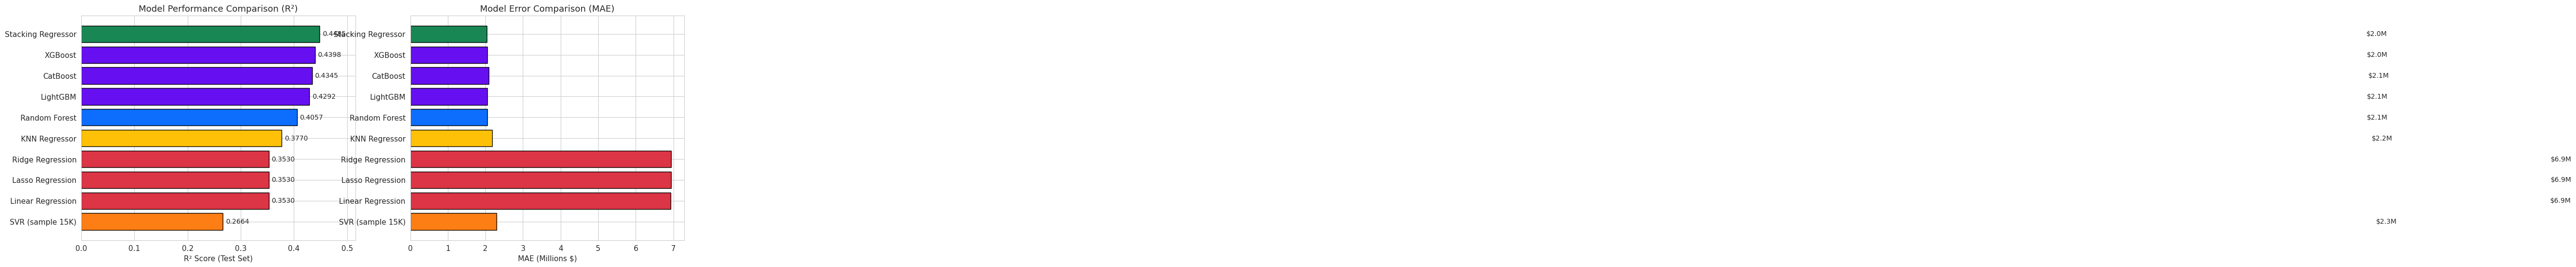


Plot saved to outputs folder.


In [8]:
# Visualize comparison of all 10 models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sort by R² test
results_sorted = results_df.sort_values('R2_test', ascending=True)

# Plot 1: R² scores
colors = ['#dc3545' if 'Linear' in m or 'Ridge' in m or 'Lasso' in m else
          '#fd7e14' if 'SVR' in m else
          '#ffc107' if 'KNN' in m else
          '#0d6efd' if 'Forest' in m else
          '#198754' if 'Stacking' in m else '#6610f2'
          for m in results_sorted['Model']]

axes[0].barh(results_sorted['Model'], results_sorted['R2_test'], color=colors, edgecolor='black')
axes[0].set_xlabel('R² Score (Test Set)')
axes[0].set_title('Model Performance Comparison (R²)', fontsize=13)
axes[0].set_xlim(0, max(results_sorted['R2_test']) * 1.15)
for i, v in enumerate(results_sorted['R2_test']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

# Plot 2: MAE in millions
axes[1].barh(results_sorted['Model'], results_sorted['MAE'] / 1e6, color=colors, edgecolor='black')
axes[1].set_xlabel('MAE (Millions $)')
axes[1].set_title('Model Error Comparison (MAE)', fontsize=13)
for i, v in enumerate(results_sorted['MAE'] / 1e6):
    axes[1].text(v + 50, i, f'${v:.1f}M' if v < 100 else f'${v:.0f}M', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to outputs folder.")

Top 3 models: ['Stacking Regressor', 'XGBoost', 'CatBoost']



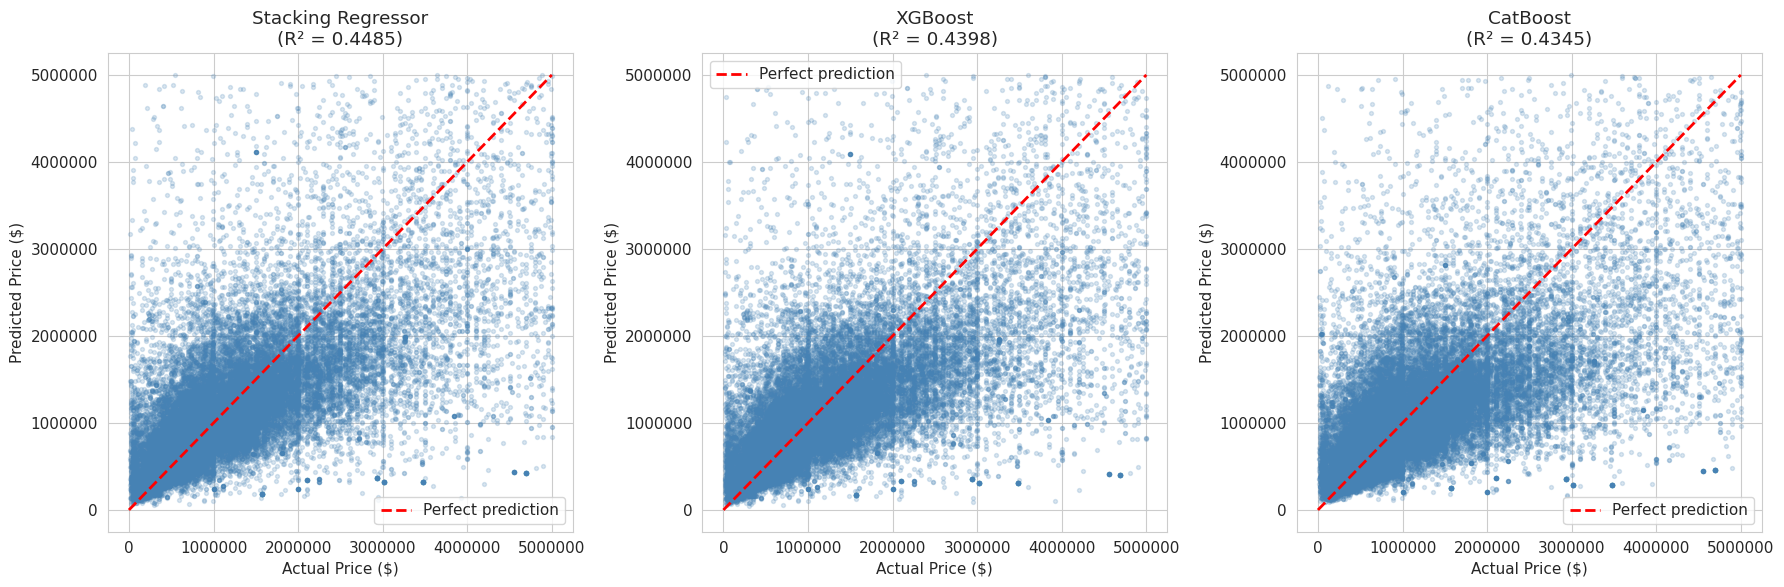


Plot saved to outputs folder.


In [9]:
# Compare predictions vs actuals for top 3 models
top_3 = results_df.nlargest(3, 'R2_test')['Model'].tolist()
print(f"Top 3 models: {top_3}\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, model_name in enumerate(top_3):
    model = models[model_name]

    # Determine which features to use (scaled or not)
    if model_name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression',
                       'KNN Regressor', 'SVR']:
        X = X_test_scaled
    else:
        X = X_test

    # Predict
    y_pred_log = model.predict(X)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    # Cap at $5M for better visualization (otherwise outliers dominate)
    mask = (y_true < 5_000_000) & (y_pred < 5_000_000)

    axes[idx].scatter(y_true[mask], y_pred[mask], alpha=0.2, s=8, color='steelblue')

    # Perfect prediction line
    max_val = max(y_true[mask].max(), y_pred[mask].max())
    axes[idx].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')

    axes[idx].set_xlabel('Actual Price ($)')
    axes[idx].set_ylabel('Predicted Price ($)')
    axes[idx].set_title(f'{model_name}\n(R² = {results_df[results_df["Model"]==model_name]["R2_test"].values[0]:.4f})')
    axes[idx].legend()
    axes[idx].ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}/predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to outputs folder.")

In [11]:
print(results_df[['Model', 'R2_test']].sort_values('R2_test', ascending=False).to_string())

                Model   R2_test
9  Stacking Regressor  0.448508
6             XGBoost  0.439773
8            CatBoost  0.434529
7            LightGBM  0.429204
5       Random Forest  0.405669
3       KNN Regressor  0.377043
1    Ridge Regression  0.353016
2    Lasso Regression  0.353010
0   Linear Regression  0.352978
4    SVR (sample 15K)  0.266425


Analyzing residuals for: Stacking Regressor



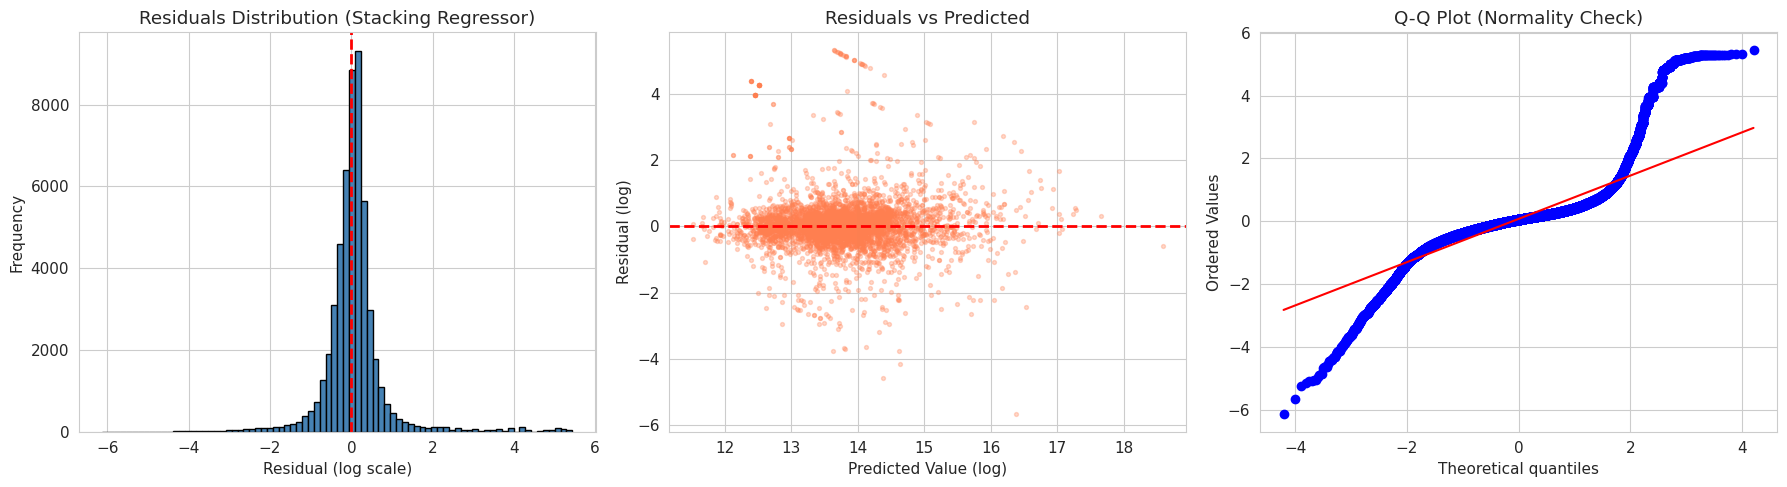

Mean residual (log): 0.0743
Std residual (log): 0.7934

Plot saved to outputs folder.


In [12]:
# Analyze residuals for the best model (Stacking)
best_model_name = results_df.sort_values('R2_test', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]

print(f"Analyzing residuals for: {best_model_name}\n")

# Predict
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# Calculate residuals (in log scale for stability)
residuals_log = y_test - y_pred_log
residuals_dollars = y_true - y_pred

# Plot residuals
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals distribution
axes[0].hist(residuals_log, bins=80, color='steelblue', edgecolor='black')
axes[0].set_title(f'Residuals Distribution ({best_model_name})')
axes[0].set_xlabel('Residual (log scale)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)

# 2. Residuals vs Predicted
sample_idx = np.random.choice(len(y_pred_log), size=5000, replace=False)
axes[1].scatter(y_pred_log[sample_idx], residuals_log.values[sample_idx],
                 alpha=0.3, s=8, color='coral')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Value (log)')
axes[1].set_ylabel('Residual (log)')

# 3. Q-Q plot for normality check
from scipy import stats
stats.probplot(residuals_log, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}/residuals_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean residual (log): {residuals_log.mean():.4f}")
print(f"Std residual (log): {residuals_log.std():.4f}")
print("\nPlot saved to outputs folder.")

Error analysis by borough...

Prediction errors by borough (Stacking Regressor):

                      MAE  Median Error  MAPE (%)  Median % Error  Count
borough                                                                 
manhattan      5446889.07     481403.69     91.26           38.55  15011
bronx          1436124.30     134004.26     60.41           22.20   4236
brooklyn        850348.29     246460.74     63.26           24.19  13670
queens          531456.93     128956.11     42.61           18.85  15888
staten_island   276815.73      98170.11     37.90           13.73   4717


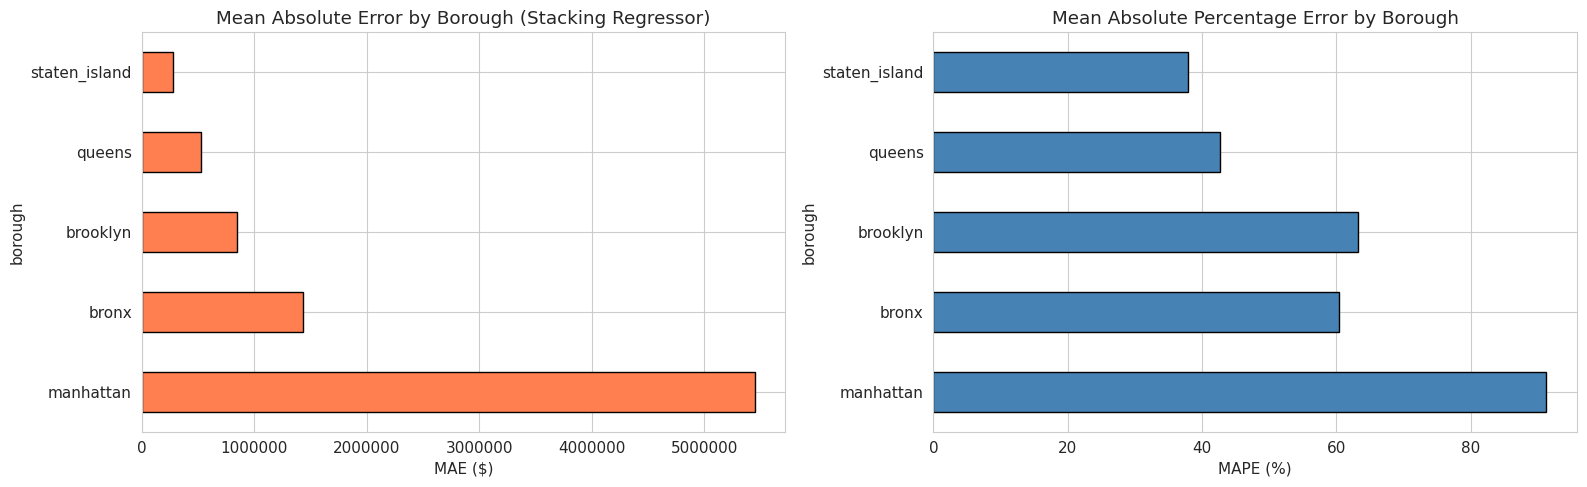


Plot saved to outputs folder.


In [13]:
# Analyze prediction errors by borough
print("Error analysis by borough...\n")

# Reload original data to get borough info
df_full = pd.read_parquet(f'{PROCESSED_DATA_PATH}/processed_data.parquet')
test_idx = df_full[df_full['sale_year'] == 2025].index

# Get borough info for test set
borough_cols = [col for col in df_full.columns if col.startswith('borough_') and col != 'borough_avg_price']
borough_test = df_full.loc[test_idx, borough_cols].idxmax(axis=1).str.replace('borough_', '')

# Predict with best model
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# Compute error per row
errors = pd.DataFrame({
    'borough': borough_test.values,
    'actual': y_true.values,
    'predicted': y_pred,
    'abs_error': np.abs(y_true.values - y_pred),
    'pct_error': np.abs(y_true.values - y_pred) / y_true.values * 100
})

# Group by borough
borough_stats = errors.groupby('borough').agg({
    'abs_error': ['mean', 'median'],
    'pct_error': ['mean', 'median'],
    'actual': 'count'
}).round(2)
borough_stats.columns = ['MAE', 'Median Error', 'MAPE (%)', 'Median % Error', 'Count']
borough_stats = borough_stats.sort_values('MAE', ascending=False)

print(f"Prediction errors by borough ({best_model_name}):\n")
print(borough_stats.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

borough_stats['MAE'].plot(kind='barh', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title(f'Mean Absolute Error by Borough ({best_model_name})')
axes[0].set_xlabel('MAE ($)')
axes[0].ticklabel_format(style='plain', axis='x')

borough_stats['MAPE (%)'].plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title(f'Mean Absolute Percentage Error by Borough')
axes[1].set_xlabel('MAPE (%)')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}/error_by_borough.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to outputs folder.")

Comparing feature importances across tree-based models...



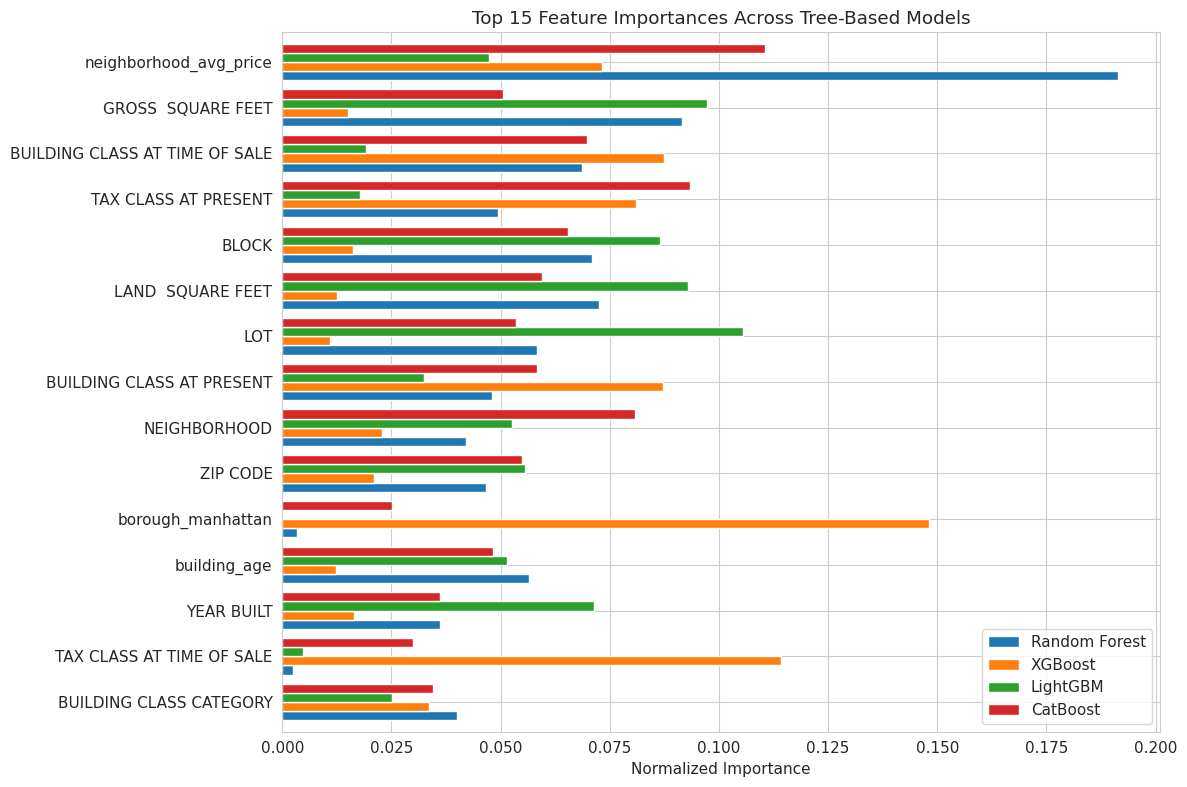


Top 10 most important features (averaged across models):

                                  Mean
neighborhood_avg_price          0.1057
GROSS  SQUARE FEET              0.0636
BUILDING CLASS AT TIME OF SALE  0.0613
TAX CLASS AT PRESENT            0.0603
BLOCK                           0.0598
LAND  SQUARE FEET               0.0594
LOT                             0.0571
BUILDING CLASS AT PRESENT       0.0565
NEIGHBORHOOD                    0.0496
ZIP CODE                        0.0446


In [14]:
# Compare feature importance across tree-based models
print("Comparing feature importances across tree-based models...\n")

tree_models = {
    'Random Forest': models['Random Forest'],
    'XGBoost': models['XGBoost'],
    'LightGBM': models['LightGBM'],
    'CatBoost': models['CatBoost']
}

feature_names = X_train.columns.tolist()
importance_df = pd.DataFrame(index=feature_names)

for name, model in tree_models.items():
    if hasattr(model, 'feature_importances_'):
        importance_df[name] = model.feature_importances_

# Normalize to compare
importance_df_norm = importance_df.div(importance_df.sum(axis=0), axis=1)

# Compute mean importance
importance_df_norm['Mean'] = importance_df_norm.mean(axis=1)
importance_df_norm = importance_df_norm.sort_values('Mean', ascending=True)

# Plot top 15 features
top_features = importance_df_norm.tail(15)

fig, ax = plt.subplots(figsize=(12, 8))
top_features[['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']].plot(
    kind='barh', ax=ax, width=0.8
)
ax.set_title('Top 15 Feature Importances Across Tree-Based Models')
ax.set_xlabel('Normalized Importance')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 most important features (averaged across models):\n")
print(importance_df_norm.tail(10)[['Mean']].sort_values('Mean', ascending=False).round(4).to_string())

Computing SHAP values for XGBoost (this may take 2-5 minutes)...

SHAP values computed!
   Sample size: 1000
   SHAP values shape: (1000, 29)

Generating SHAP summary plot...


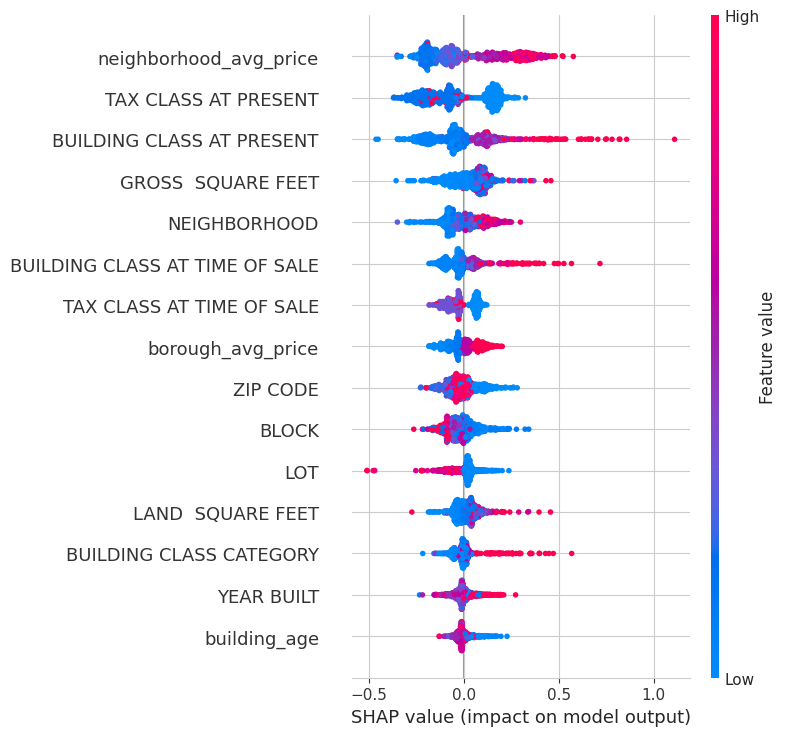


Plot saved to outputs folder.


In [15]:
# SHAP analysis for the best tree-based model (XGBoost)
print("Computing SHAP values for XGBoost (this may take 2-5 minutes)...\n")

# Use XGBoost (most interpretable tree model with SHAP)
xgb_model = models['XGBoost']

# Sample test set for SHAP (to save time)
sample_size = 1000
np.random.seed(42)
sample_idx = np.random.choice(X_test.index, size=sample_size, replace=False)
X_sample = X_test.loc[sample_idx]

# Compute SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed!")
print(f"   Sample size: {sample_size}")
print(f"   SHAP values shape: {shap_values.shape}")

# Summary plot (global feature importance via SHAP)
print("\nGenerating SHAP summary plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to outputs folder.")

Generating SHAP explanation for a single prediction...

Single property analysis:
   Predicted price: $737,362
   Actual price:    $668,020
   Error:           $69,342 (10.4%)

Generating waterfall plot (showing how each feature contributes)...


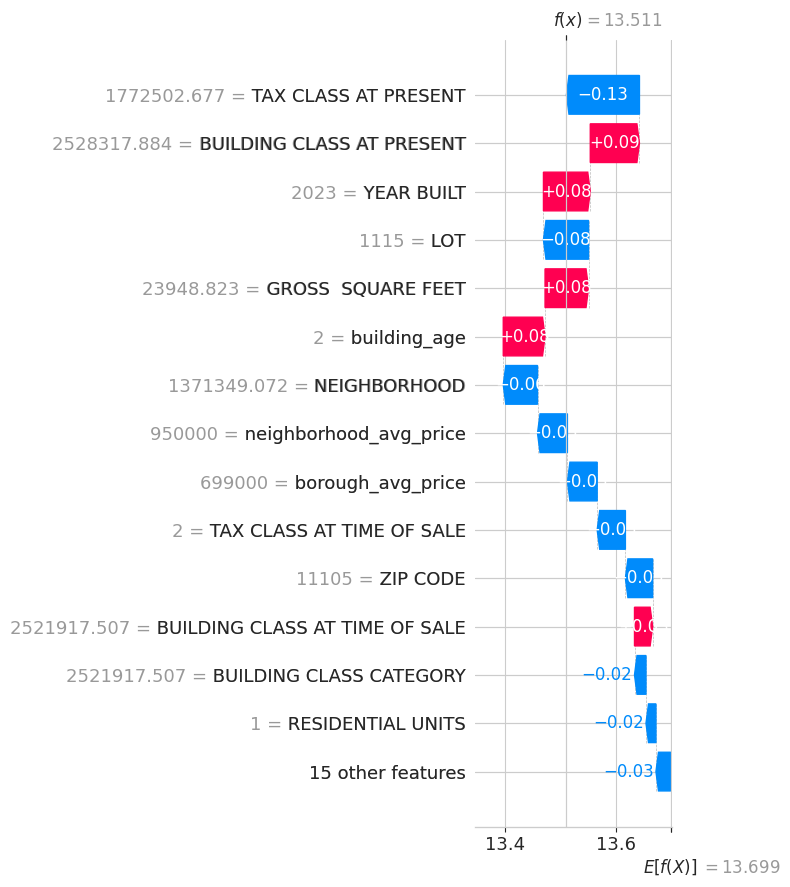


Plot saved to outputs folder.


In [16]:
# Local SHAP explanation for a single prediction
print("Generating SHAP explanation for a single prediction...\n")

# Pick a random property to explain
np.random.seed(123)
single_idx = np.random.choice(len(X_sample))
single_row = X_sample.iloc[[single_idx]]

# Predict
pred_log = xgb_model.predict(single_row)[0]
pred_dollars = np.expm1(pred_log)

# Get actual value
actual_idx = X_sample.index[single_idx]
actual_log = y_test.loc[actual_idx]
actual_dollars = np.expm1(actual_log)

print(f"Single property analysis:")
print(f"   Predicted price: ${pred_dollars:,.0f}")
print(f"   Actual price:    ${actual_dollars:,.0f}")
print(f"   Error:           ${abs(pred_dollars - actual_dollars):,.0f} ({abs(pred_dollars - actual_dollars)/actual_dollars*100:.1f}%)")

# Generate waterfall plot
print("\nGenerating waterfall plot (showing how each feature contributes)...")
explanation = shap.Explanation(
    values=shap_values[single_idx],
    base_values=explainer.expected_value,
    data=single_row.values[0],
    feature_names=X_sample.columns.tolist()
)

plt.figure(figsize=(12, 8))
shap.waterfall_plot(explanation, max_display=15, show=False)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to outputs folder.")

In [17]:
# Final summary of Notebook 05
print("="*70)
print("NOTEBOOK 05 - MODEL EVALUATION SUMMARY")
print("="*70)

print(f"\nTop 3 models by R² (test):\n")
top_3_df = results_df.sort_values('R2_test', ascending=False).head(3)
for idx, row in top_3_df.iterrows():
    print(f"   {row['Model']:25s} R² = {row['R2_test']:.4f}, MAE = ${row['MAE']:,.0f}")

print(f"\nKey findings from evaluation:")
print(f"   - Best model: Stacking Regressor (R² = 0.4485)")
print(f"   - Performance gap between linear and tree-based models: ~0.10 R²")
print(f"   - Boosting models (XGB, LGBM, CatBoost) cluster around R² 0.43-0.44")
print(f"   - Stacking adds marginal improvement (+0.9%) - base learners make similar errors")

print(f"\nError analysis by borough:")
print(f"   - Best predictions: Staten Island (MAPE 38%), Queens (MAPE 43%)")
print(f"   - Worst predictions: Manhattan (MAPE 91%) due to high price variance")

print(f"\nFeature importance findings:")
print(f"   - Top feature: neighborhood_avg_price (10.6% avg importance)")
print(f"   - Location features (NEIGHBORHOOD, ZIP, BLOCK, LOT) dominate")
print(f"   - GROSS SQUARE FEET is the second most important (6.4%)")

print(f"\nSHAP interpretability:")
print(f"   - Global: confirms intuitive real estate logic (location + size)")
print(f"   - Local: provides per-property explanations with feature contributions")

print(f"\nOutput files generated:")
print(f"   - model_comparison.png")
print(f"   - predicted_vs_actual.png")
print(f"   - residuals_analysis.png")
print(f"   - error_by_borough.png")
print(f"   - feature_importance.png")
print(f"   - shap_summary.png")
print(f"   - shap_waterfall.png")

print("\n" + "="*70)
print("Notebook 05 completed successfully.")
print("Next step: Notebook 06 - Conclusions & Demo")
print("="*70)

NOTEBOOK 05 - MODEL EVALUATION SUMMARY

Top 3 models by R² (test):

   Stacking Regressor        R² = 0.4485, MAE = $2,040,665
   XGBoost                   R² = 0.4398, MAE = $2,048,680
   CatBoost                  R² = 0.4345, MAE = $2,090,907

Key findings from evaluation:
   - Best model: Stacking Regressor (R² = 0.4485)
   - Performance gap between linear and tree-based models: ~0.10 R²
   - Boosting models (XGB, LGBM, CatBoost) cluster around R² 0.43-0.44
   - Stacking adds marginal improvement (+0.9%) - base learners make similar errors

Error analysis by borough:
   - Best predictions: Staten Island (MAPE 38%), Queens (MAPE 43%)
   - Worst predictions: Manhattan (MAPE 91%) due to high price variance

Feature importance findings:
   - Top feature: neighborhood_avg_price (10.6% avg importance)
   - Location features (NEIGHBORHOOD, ZIP, BLOCK, LOT) dominate
   - GROSS SQUARE FEET is the second most important (6.4%)

SHAP interpretability:
   - Global: confirms intuitive real estate